In [3]:
cd ../..

/home/sangonvi/Cefet/repositories/rionowcastdf


Loading summary parquet...
            timestamp  rain_pixels  rain_fraction       mean       std  \
0 2011-01-17 15:36:00          184       0.031293  31.663322  8.129971   
1 2011-01-17 15:44:00          207       0.035204  29.805325  7.576298   
2 2011-01-17 15:46:00          213       0.036224  29.541319  7.312479   
3 2011-01-17 15:48:00          197       0.033503  29.265385  7.915115   
4 2011-01-17 15:50:00          192       0.032653  29.176849  7.859232   

   maximum       volume        p50   p90        p95   p99  
0     45.0  5826.051270  30.000000  40.0  45.000000  45.0  
1     45.0  6169.702148  30.000000  40.0  43.898239  45.0  
2     45.0  6292.300781  30.000000  40.0  45.000000  45.0  
3     45.0  5765.280762  30.000000  40.0  44.441284  45.0  
4     45.0  5601.955078  28.380985  40.0  43.221180  45.0  
                        timestamp   rain_pixels  rain_fraction          mean  \
count                     2828520  2.828520e+06   2.828520e+06  2.828520e+06   
mean   2

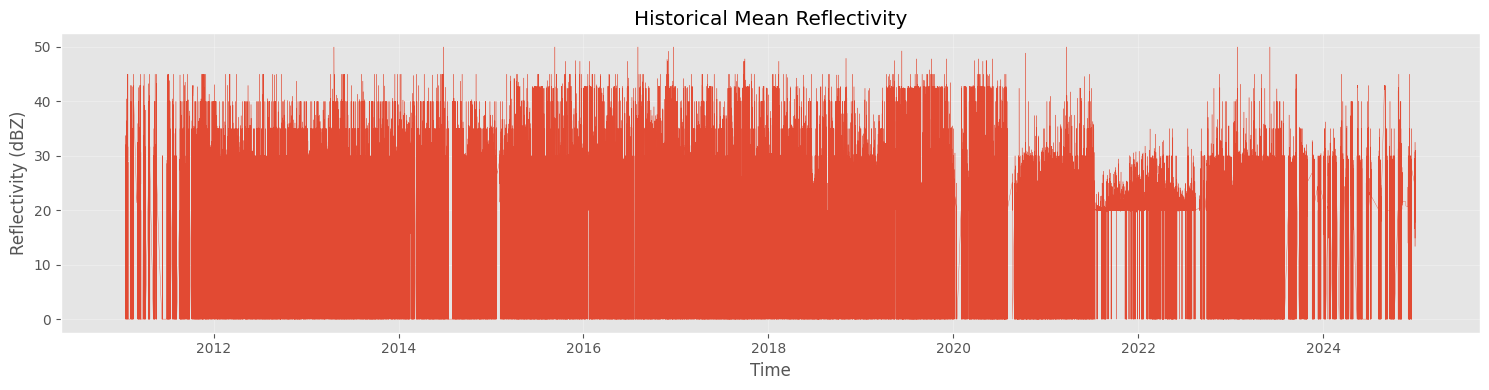

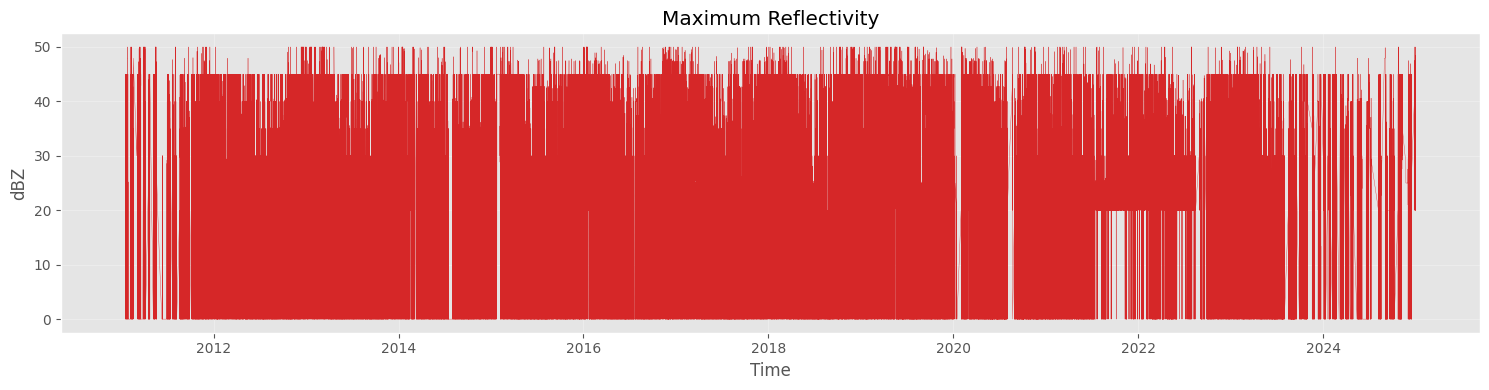

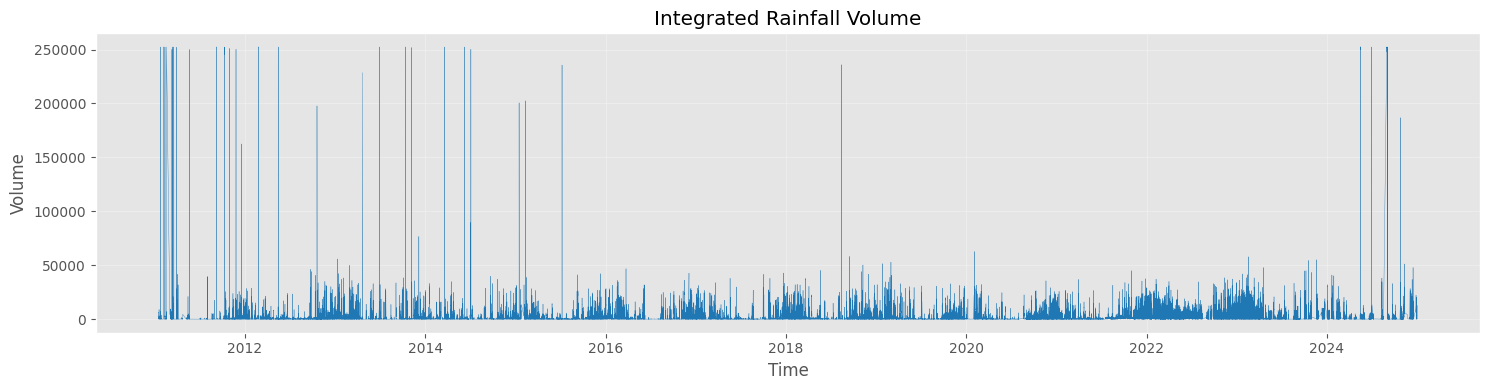

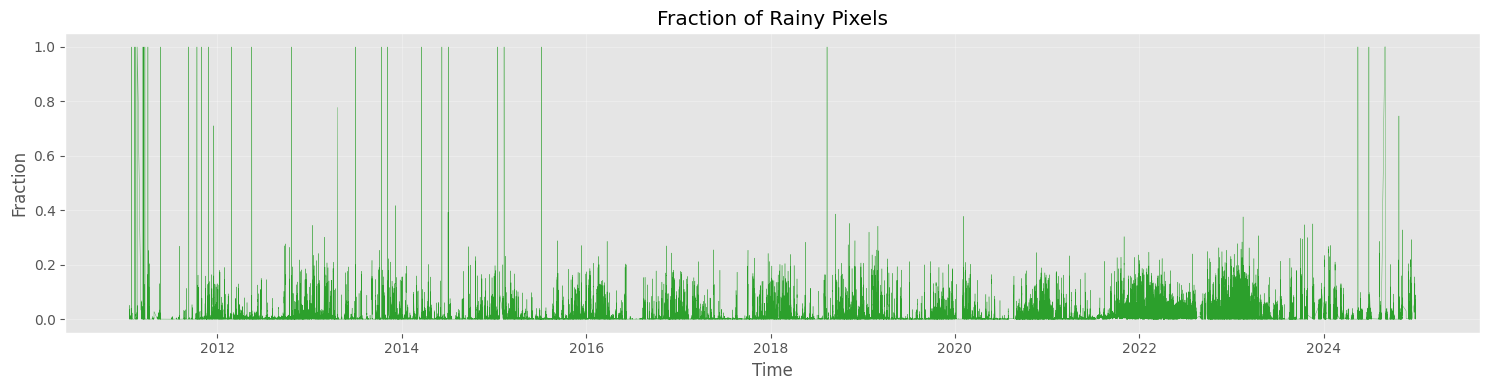

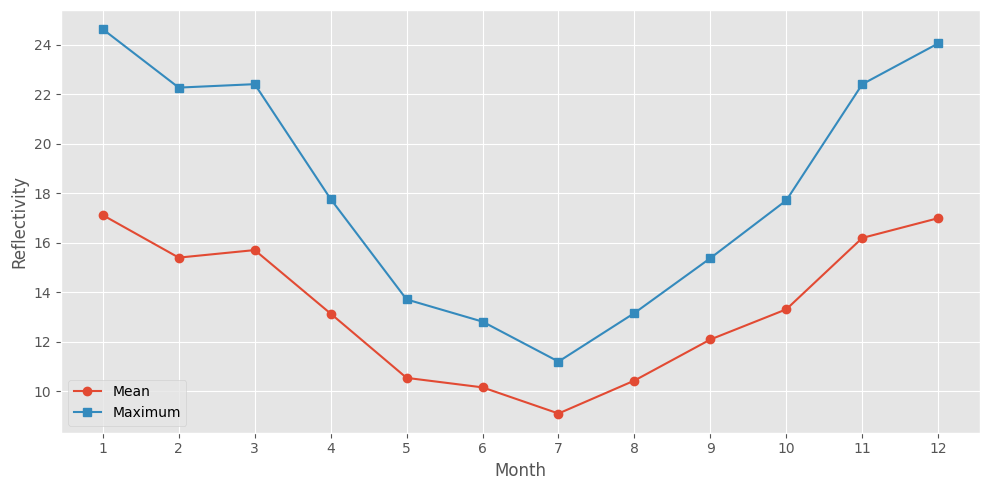

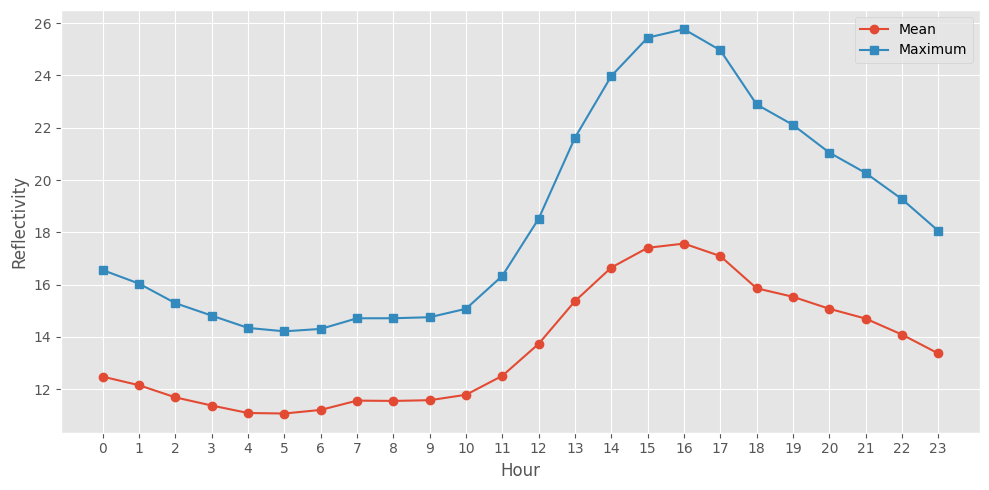

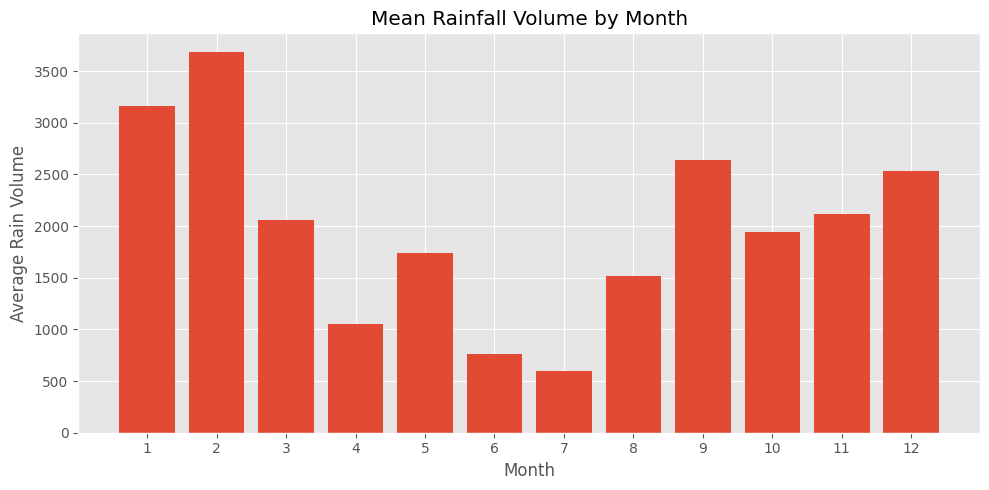

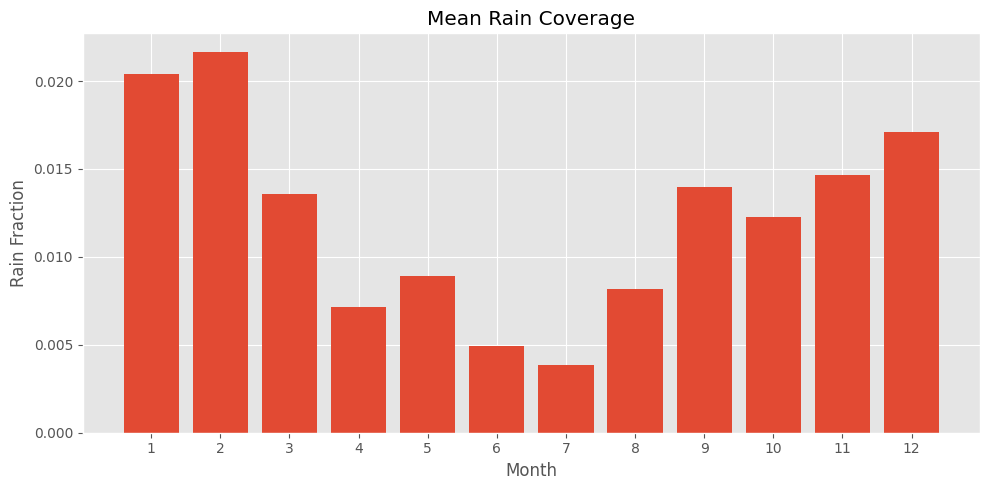

/tmp/ipykernel_3780/2770745657.py:401: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_3780/2770745657.py:403: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(
/home/sangonvi/miniconda3/envs/atmoseer/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


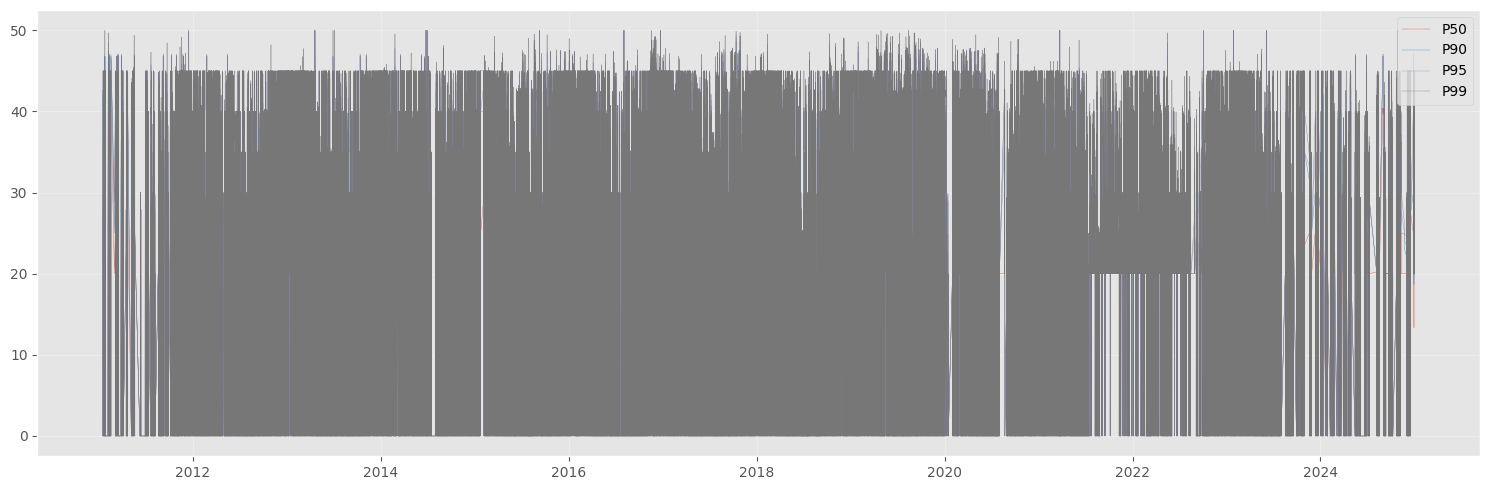


Temporal climatology summary
Period            : 2011-01-17 15:36:00 -> 2024-12-31 00:00:00
Records           : 2,828,520
Mean reflectivity : 13.539
Maximum observed  : 50.000
Mean rain fraction: 0.0125
Average volume    : 2018.89


In [4]:
# =============================================================================
# Notebook 01
# Temporal Climatology of Rio de Janeiro Radar Dataset
#
# Dataset:
#     summary.parquet
#
# Author:
#     Vinicius Gonçalves dos Santos
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

# =============================================================================
# Paths
# =============================================================================

DATASET = Path("datasets/radar_statistics/summary.parquet")

FIGURES = Path("figures/notebook01")

FIGURES.mkdir(
    parents=True,
    exist_ok=True
)

# =============================================================================
# Load data
# =============================================================================

print("Loading summary parquet...")

df = pd.read_parquet(DATASET)

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp")

print(df.head())

print(df.describe())

# =============================================================================
# Create temporal features
# =============================================================================

df["year"] = df.timestamp.dt.year

df["month"] = df.timestamp.dt.month

df["hour"] = df.timestamp.dt.hour

df["dayofyear"] = df.timestamp.dt.dayofyear

df["weekday"] = df.timestamp.dt.dayofweek

print(df.head())

# =============================================================================
# Figure 1
# Mean reflectivity
# =============================================================================

plt.figure(figsize=(15,4))

plt.plot(
    df.timestamp,
    df["mean"],
    linewidth=0.25
)

plt.title("Historical Mean Reflectivity")

plt.ylabel("Reflectivity (dBZ)")

plt.xlabel("Time")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES/"figure01_mean_reflectivity.png",
    dpi=300
)

plt.show()

# =============================================================================
# Figure 2
# Maximum reflectivity
# =============================================================================

plt.figure(figsize=(15,4))

plt.plot(
    df.timestamp,
    df["maximum"],
    linewidth=0.25,
    color="tab:red"
)

plt.title("Maximum Reflectivity")

plt.ylabel("dBZ")

plt.xlabel("Time")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES/"figure02_maximum_reflectivity.png",
    dpi=300
)

plt.show()

# =============================================================================
# Figure 3
# Rain volume
# =============================================================================

plt.figure(figsize=(15,4))

plt.plot(
    df.timestamp,
    df.volume,
    linewidth=0.25,
    color="tab:blue"
)

plt.title("Integrated Rainfall Volume")

plt.ylabel("Volume")

plt.xlabel("Time")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES/"figure03_volume.png",
    dpi=300
)

plt.show()

# =============================================================================
# Figure 4
# Rain fraction
# =============================================================================

plt.figure(figsize=(15,4))

plt.plot(
    df.timestamp,
    df.rain_fraction,
    linewidth=0.25,
    color="tab:green"
)

plt.title("Fraction of Rainy Pixels")

plt.ylabel("Fraction")

plt.xlabel("Time")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES/"figure04_rain_fraction.png",
    dpi=300
)

plt.show()

# =============================================================================
# Figure 5
# Monthly climatology
# =============================================================================

monthly = (

    df

    .groupby("month")

    .agg({

        "mean":"mean",

        "maximum":"mean",

        "volume":"mean",

        "rain_fraction":"mean"

    })

)

fig,ax = plt.subplots(figsize=(10,5))

ax.plot(
    monthly.index,
    monthly["mean"],
    marker="o",
    label="Mean"
)

ax.plot(
    monthly.index,
    monthly["maximum"],
    marker="s",
    label="Maximum"
)

ax.set_xticks(range(1,13))

ax.set_xlabel("Month")

ax.set_ylabel("Reflectivity")

ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES/"figure05_monthly_climatology.png",
    dpi=300
)

plt.show()

# =============================================================================
# Figure 6
# Hourly climatology
# =============================================================================

hourly = (

    df

    .groupby("hour")

    .agg({

        "mean":"mean",

        "maximum":"mean",

        "volume":"mean",

        "rain_fraction":"mean"

    })

)

fig,ax = plt.subplots(figsize=(10,5))

ax.plot(
    hourly.index,
    hourly["mean"],
    marker="o",
    label="Mean"
)

ax.plot(
    hourly.index,
    hourly["maximum"],
    marker="s",
    label="Maximum"
)

ax.set_xticks(range(24))

ax.set_xlabel("Hour")

ax.set_ylabel("Reflectivity")

ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES/"figure06_hourly_climatology.png",
    dpi=300
)

plt.show()

# =============================================================================
# Figure 7
# Monthly rainfall volume
# =============================================================================

plt.figure(figsize=(10,5))

plt.bar(
    monthly.index,
    monthly.volume
)

plt.xticks(range(1,13))

plt.xlabel("Month")

plt.ylabel("Average Rain Volume")

plt.title("Mean Rainfall Volume by Month")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure07_monthly_volume.png",
    dpi=300
)

plt.show()

# =============================================================================
# Figure 8
# Monthly rain coverage
# =============================================================================

plt.figure(figsize=(10,5))

plt.bar(
    monthly.index,
    monthly.rain_fraction
)

plt.xticks(range(1,13))

plt.xlabel("Month")

plt.ylabel("Rain Fraction")

plt.title("Mean Rain Coverage")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure08_monthly_rain_fraction.png",
    dpi=300
)

plt.show()

# =============================================================================
# Figure 9
# Reflectivity percentiles
# =============================================================================

plt.figure(figsize=(15,5))

plt.plot(
    df.timestamp,
    df.p50,
    linewidth=0.25,
    label="P50"
)

plt.plot(
    df.timestamp,
    df.p90,
    linewidth=0.25,
    label="P90"
)

plt.plot(
    df.timestamp,
    df.p95,
    linewidth=0.25,
    label="P95"
)

plt.plot(
    df.timestamp,
    df.p99,
    linewidth=0.25,
    label="P99"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES/"figure09_percentiles.png",
    dpi=300
)

plt.show()

# =============================================================================
# Summary
# =============================================================================

print()

print("="*70)

print("Temporal climatology summary")

print("="*70)

print(f"Period            : {df.timestamp.min()} -> {df.timestamp.max()}")

print(f"Records           : {len(df):,}")

print(f"Mean reflectivity : {df['mean'].mean():.3f}")

print(f"Maximum observed  : {df.maximum.max():.3f}")

print(f"Mean rain fraction: {df.rain_fraction.mean():.4f}")

print(f"Average volume    : {df.volume.mean():.2f}")

print("="*70)